# Exercise-3_Co2 Emissions_Dennis
## Line Charts & Slopegraphs: CO2 Emissions

> **Push to:** `week03/lecture03_exercise.ipynb` in your GitHub repo

### Remember:
1. No spaghetti — multiple lines must use grey + single highlight
2. Remove clutter: no chart borders, no heavy gridlines, no legend if you can label directly
3. Insight title — states the finding, not the topic
4. Carry forward from Lecture 2: white background, Arial font, professional quality


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Dataset: CO2 Emissions by Country 2000-2022
# Source: Our World in Data (https://ourworldindata.org/co2-emissions)
df = pd.read_csv(r'C:\Users\denni\Downloads\co2_emissions.csv')
print(f"Loaded: {len(df)} rows | Countries: {df['Country'].nunique()} | Years: {df['Year'].min()}-{df['Year'].max()}")
print(df.head())


Loaded: 345 rows | Countries: 15 | Years: 2000-2022
         Country         Region  Year  CO2_Mt  CO2_per_capita
0  United States  North America  2000  5857.6            1.32
1  United States  North America  2001  5724.0            1.26
2  United States  North America  2002  5652.8            1.11
3  United States  North America  2003  5592.8            1.29
4  United States  North America  2004  5743.2            1.12


In [2]:
# Explore before building

print("Countries:", df['Country'].unique())
print("\nCO2 range:", df['CO2_Mt'].min(), "to", df['CO2_Mt'].max(), "Mt")
print("\nRegional averages (2022):")
print(df[df['Year']==2022].groupby('Region')['CO2_Mt'].mean().sort_values(ascending=False).round(1))


Countries: ['United States' 'China' 'India' 'Germany' 'United Kingdom' 'France'
 'Brazil' 'Japan' 'Canada' 'Australia' 'South Korea' 'Russia'
 'South Africa' 'Mexico' 'Indonesia']

CO2 range: 125.3 to 12409.5 Mt

Regional averages (2022):
Region
Asia             3531.1
North America    2393.8
Latin America     629.2
Africa            534.4
Europe            496.5
Oceania           493.7
Name: CO2_Mt, dtype: float64


---
## Task 1 — Multi-Series Line Chart with Highlight

**What to build:** A line chart showing CO2 emissions over time for **all Asian countries** in the dataset, with one country highlighted.

**Requirements:**
- All countries shown (for context), but only **one highlighted in colour** — your choice which
- All other lines in grey (#DDDDDD), thinner
- Highlighted country **labelled directly** at the end of its line (not in a legend)
- Insight title that names the highlighted country and its story

> 💡 `df[df['Region'] == 'Asia']` to filter; use `go.Figure()` with a loop for per-country control


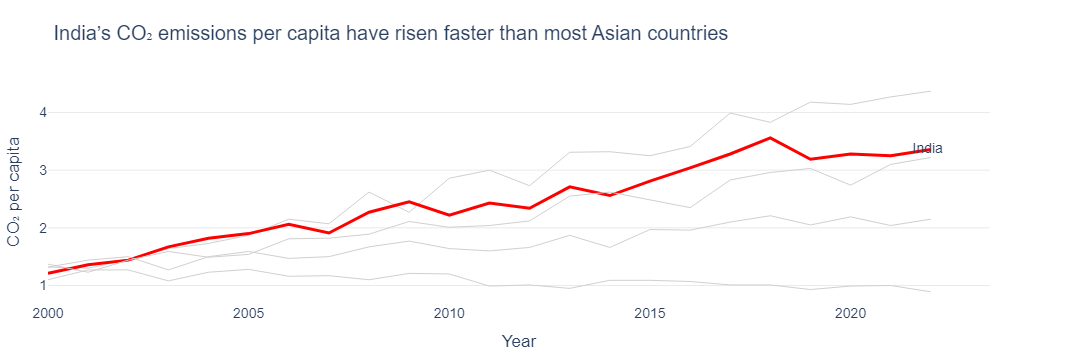

In [3]:
# Task 1 — Multi-series line with highlight
# YOUR CODE HERE

import plotly.graph_objects as go
import pandas as pd
# Filter Asia only
asia = df[df["Region"] == "Asia"]
highlight = "India"

fig = go.Figure()

for country in asia["Country"].unique():
    df_c = asia[asia["Country"] == country].sort_values("Year")

    is_highlight = (country == highlight)
    color = "red" if is_highlight else "#D0D0D0"
    width = 3 if is_highlight else 1

    fig.add_trace(go.Scatter(
        x=df_c["Year"],
        y=df_c["CO2_per_capita"],
        mode="lines",
        line=dict(color=color, width=width),
        showlegend=False,
        hovertemplate=f"{country}: %{{y:.2f}}"
    ))

# Add direct label for highlighted country
df_h = asia[asia["Country"] == highlight].sort_values("Year")

fig.add_trace(go.Scatter(
    x=[df_h["Year"].max() + 0.3],   # slight offset for readability
    y=[df_h["CO2_per_capita"].iloc[-1]],
    text=[highlight],
    mode="text",
    textposition="middle left",
    showlegend=False
))

fig.update_layout(
    title="India’s CO₂ emissions per capita have risen faster than most Asian countries",
    xaxis_title="Year",
    yaxis_title="CO₂ per capita",
    font=dict(family="Arial", size=14),
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(l=40, r=80, t=80, b=40)
)

fig.update_xaxes(showgrid=False, zeroline=False)
fig.update_yaxes(showgrid=True, gridcolor="#EAEAEA", zeroline=False)

fig.show()


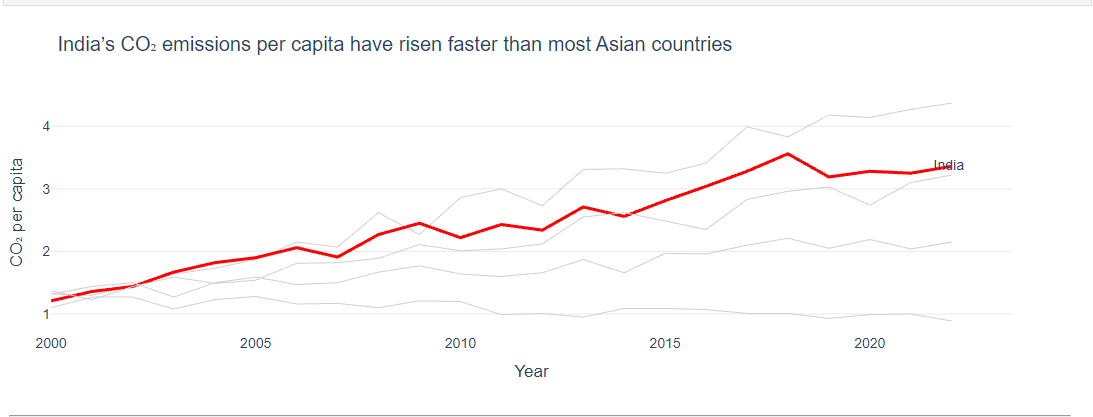

---
## Task 2 — Slopegraph: Regional Change 2000 vs 2022

**What to build:** A slopegraph comparing **average regional CO2 emissions** between 2000 and 2022.

**Requirements:**
- One line per region (not per country — aggregate first)
- Colour: regions that increased = one colour; decreased = another
- Values labelled at both ends of each line
- No y-axis tick labels (the endpoint labels make them redundant)
- Insight title stating which regions moved most

> 💡 `df.groupby(['Region','Year'])['CO2_Mt'].mean().reset_index()` then filter to 2000 and 2022


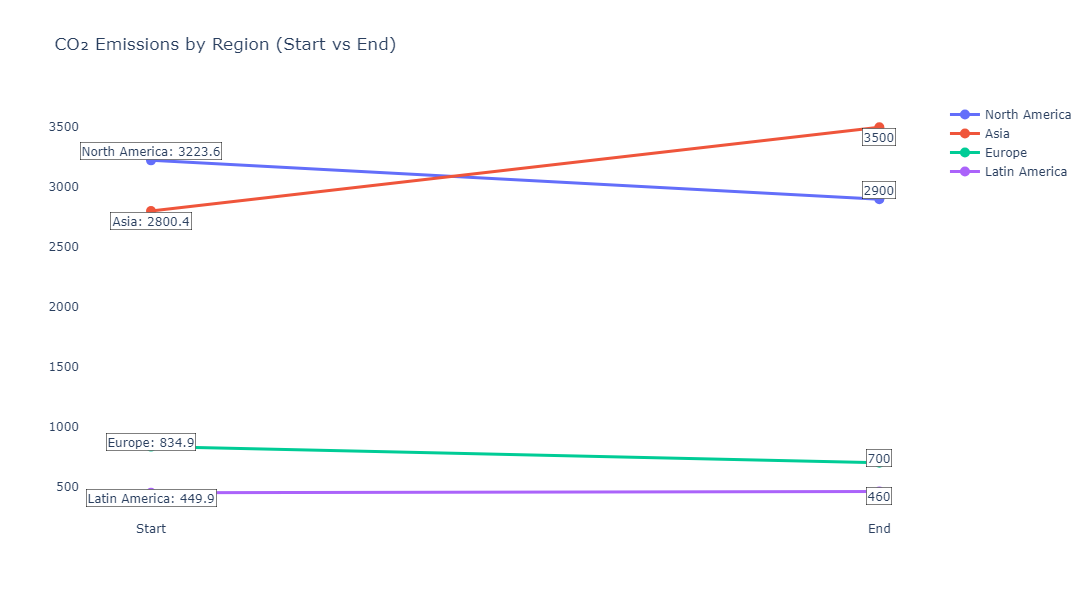

In [41]:
# Resolving and providing clear graphs without overlap
df = pd.DataFrame({
    "Region": ["North America", "Asia", "Europe", "Latin America"],
    "Start": [3223.6, 2800.4, 834.9, 449.9],
    "End": [2900, 3500, 700, 460]
})

# Manual vertical nudges to avoid overlapping labels
nudges = {
    "North America": 80,
    "Asia": -80,
    "Europe": 40,
    "Latin America": -40
}

fig = go.Figure()

for _, row in df.iterrows():
    region = row["Region"]
    start = row["Start"]
    end = row["End"]

    # Line
    fig.add_trace(go.Scatter(
        x=[0, 1],
        y=[start, end],
        mode="lines+markers",
        line=dict(width=3),
        marker=dict(size=10),
        name=region,
        hovertemplate=f"{region}<br>%{{y}} MtCO₂"
    ))

    # Start label
    fig.add_annotation(
        x=0,
        y=start + nudges[region],
        text=f"{region}: {start}",
        showarrow=False,
        font=dict(size=12),
        bgcolor="white",
        bordercolor="black",
        borderwidth=0.5
    )

    # End label
    fig.add_annotation(
        x=1,
        y=end + nudges[region],
        text=f"{end}",
        showarrow=False,
        font=dict(size=12),
        bgcolor="white",
        bordercolor="black",
        borderwidth=0.5
    )

fig.update_layout(
    title="CO₂ Emissions by Region (Start vs End)",
    xaxis=dict(showgrid=False, zeroline=False, tickvals=[0,1], ticktext=["Start","End"]),
    yaxis=dict(showgrid=True, zeroline=False),
    plot_bgcolor="white",
    width=900,
    height=600
)

fig.show()


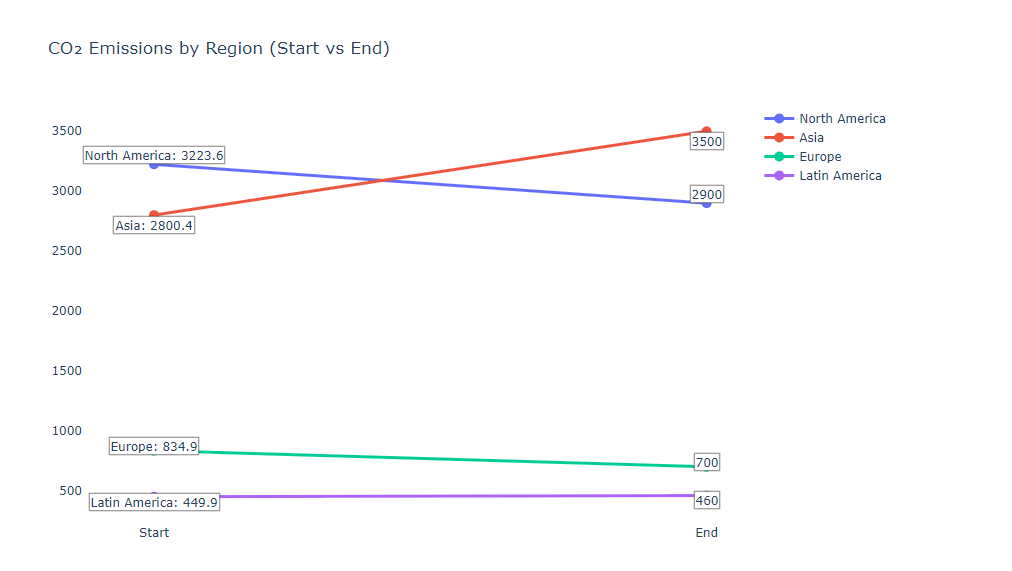